# Clasificador de tráfico de red — exploración y preparación

Este cuaderno recorre los dos primeros pasos del proyecto: entender el dataset y
dejarlo listo para entrenar.

**Dataset.** UNSW-NB15, del Australian Centre for Cyber Security. Contiene flujos
de red etiquetados con el tipo de ataque al que corresponden. Se usa la versión
publicada en Kaggle, que ya viene dividida en entrenamiento y prueba.

**El objetivo del proyecto no es sacar buena nota.** Es mostrar por qué una buena
nota global puede esconder que el modelo no detecta ninguno de los ataques que
aparecen poco, que suelen ser justo los que más importan.

## Índice

1. Carga de los datos
2. Reparto de clases
3. El baseline ingenuo
4. Estado de los datos
5. Dónde se concentran los duplicados
6. Fuga entre entrenamiento y prueba
7. Preparación y guardado


## 0. Preparación

La celda siguiente importa las bibliotecas y fija las rutas. `RAIZ` se calcula de
forma que el cuaderno funcione tanto si se ejecuta desde `notebooks/` como desde
la carpeta del proyecto.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

# La raíz del proyecto se deduce de dónde se esté ejecutando el cuaderno.
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATOS = RAIZ / "datos"
SALIDA = DATOS / "procesado"
RESULTADOS = RAIZ / "resultados"

COLUMNA_CLASE = "attack_cat"
ETIQUETAS = ("attack_cat", "label")

# Colores tomados de la paleta del portafolio, para que los gráficos encajen.
ACENTO = "#5E6AD2"
AVISO = "#e0803c"

pd.set_option("display.width", 140)
# Se imprime solo el nombre de la carpeta: la ruta completa acabaría
# guardada en la salida del cuaderno y se publicaría con el repositorio.
print("Raíz del proyecto:", RAIZ.name)

Raíz del proyecto: clasificador-trafico-red


## 1. Carga de los datos

En Kaggle el mismo dataset está subido unas veces en CSV y otras en Parquet. La
función acepta los dos formatos y da preferencia a Parquet, que ocupa menos y
conserva el tipo de cada columna.

In [2]:
def leer(nombre):
    """Devuelve el DataFrame del archivo indicado, sea Parquet o CSV."""
    for extension in (".parquet", ".csv"):
        ruta = DATOS / f"{nombre}{extension}"
        if ruta.exists():
            print(f"Leyendo {ruta.name}")
            return pd.read_parquet(ruta) if extension == ".parquet" else pd.read_csv(ruta)
    raise FileNotFoundError(
        f"No se encuentra {nombre} (.parquet ni .csv) en {DATOS}. "
        "Descarga UNSW-NB15 de Kaggle y deja los archivos ahí."
    )


train = leer("UNSW_NB15_training-set")
test = leer("UNSW_NB15_testing-set")

# Las características son todas las columnas menos las dos etiquetas.
caracteristicas = [c for c in train.columns if c not in ETIQUETAS]

print(f"\nEntrenamiento: {len(train):,} filas x {len(train.columns)} columnas")
print(f"Prueba:        {len(test):,} filas x {len(test.columns)} columnas")

Leyendo UNSW_NB15_training-set.parquet
Leyendo UNSW_NB15_testing-set.parquet

Entrenamiento: 175,341 filas x 36 columnas
Prueba:        82,332 filas x 36 columnas


In [3]:
# Un vistazo a las primeras filas para hacerse una idea del contenido.
train.head()

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,...,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label
0,0.121478,tcp,-,FIN,6,4,258,172,74.087486,14158.942383,...,0,0,1,1,0,0,0,0,Normal,0
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473373,8395.112305,...,0,0,1,1,0,0,0,0,Normal,0
2,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,1572.271851,...,0,0,1,1,0,0,0,0,Normal,0
3,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,2740.178955,...,0,0,1,1,1,1,0,0,Normal,0
4,0.449454,tcp,-,FIN,10,6,534,268,33.373825,8561.499023,...,0,0,2,1,0,0,0,0,Normal,0


## 2. Reparto de clases

Esta es la primera pregunta que hay que responder, antes de tocar ningún modelo:
**cuántas filas hay de cada tipo de ataque**. Esa proporción define todo lo demás.

In [4]:
def reparto(df, titulo=""):
    """Construye la tabla de filas y porcentaje por clase, de mayor a menor."""
    conteo = df[COLUMNA_CLASE].value_counts()
    tabla = pd.DataFrame({
        "filas": conteo,
        "porcentaje": (conteo / len(df) * 100).round(3),
    })
    if titulo:
        print(f"--- {titulo} ({len(df):,} filas) ---")
    return tabla


tabla_train = reparto(train, "Entrenamiento original")
tabla_train

--- Entrenamiento original (175,341 filas) ---


,filas,porcentaje
attack_cat,,
Normal,56000,31.938
Generic,40000,22.813
Exploits,33393,19.045
Fuzzers,18184,10.371
DoS,12264,6.994
Reconnaissance,10491,5.983
Analysis,2000,1.141
Backdoor,1746,0.996
Shellcode,1133,0.646


In [5]:
# La distancia entre la clase más común y la más rara resume el problema.
mayor, menor = tabla_train["filas"].iloc[0], tabla_train["filas"].iloc[-1]
print(f"Clase más común: {tabla_train.index[0]} ({mayor:,} filas)")
print(f"Clase más rara:  {tabla_train.index[-1]} ({menor:,} filas)")
print(f"\nProporción entre ambas: {mayor / menor:.0f} a 1")

Clase más común: Normal (56,000 filas)
Clase más rara:  Worms (130 filas)

Proporción entre ambas: 431 a 1


### El gráfico

Se dibuja en horizontal, porque los nombres de clase caben mejor, y en **escala
logarítmica**: en escala lineal la barra de `Worms` mide menos de un píxel y
desaparece.

Las clases que no llegan al 1 % del total se pintan en otro color. Son las que
van a dar problemas.

Guardado en resultados/reparto-clases.png


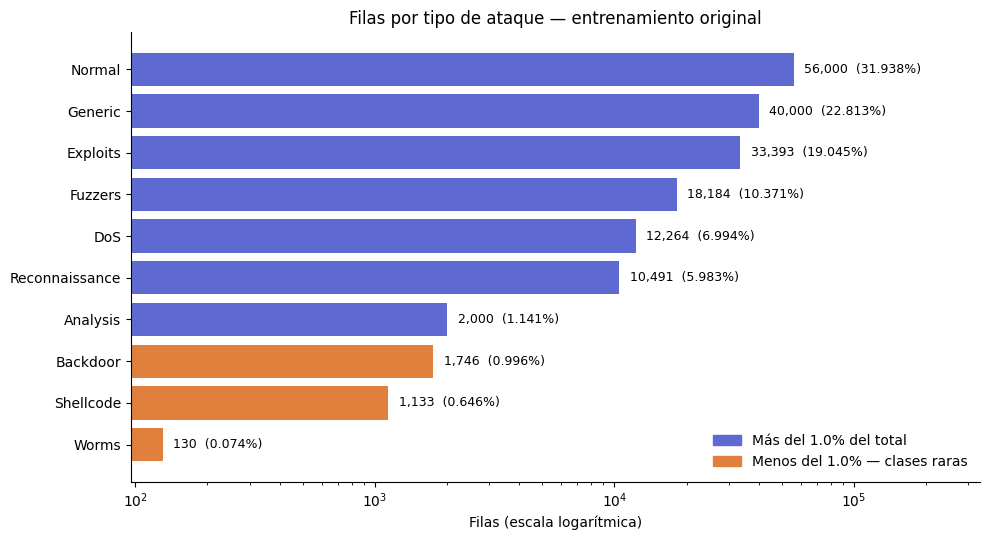

In [6]:
def grafico_reparto(tabla, titulo, archivo=None, umbral=1.0):
    """Dibuja el reparto de clases resaltando las que no llegan al umbral."""
    datos = tabla.sort_values("filas")
    colores = [AVISO if p < umbral else ACENTO for p in datos["porcentaje"]]

    fig, ax = plt.subplots(figsize=(10, 5.5))
    barras = ax.barh(datos.index, datos["filas"], color=colores)
    ax.set_xscale("log")
    ax.set_xlabel("Filas (escala logarítmica)")
    ax.set_title(titulo)

    # Cada barra se anota con su número de filas y su porcentaje.
    etiquetas = [f"  {f:,}  ({p}%)" for f, p in zip(datos["filas"], datos["porcentaje"])]
    ax.bar_label(barras, labels=etiquetas, padding=2, fontsize=9)
    ax.set_xlim(right=datos["filas"].max() * 6)

    # La leyenda se construye con parches, porque unas barras vacías no
    # conservarían el color al pasar a la leyenda.
    ax.legend(
        handles=[
            Patch(color=ACENTO, label=f"Más del {umbral}% del total"),
            Patch(color=AVISO, label=f"Menos del {umbral}% — clases raras"),
        ],
        loc="lower right",
        frameon=False,
    )

    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()

    if archivo:
        RESULTADOS.mkdir(exist_ok=True)
        fig.savefig(RESULTADOS / archivo, dpi=140)
        print(f"Guardado en resultados/{archivo}")
    plt.show()


grafico_reparto(tabla_train, "Filas por tipo de ataque — entrenamiento original",
                "reparto-clases.png")

## 3. El baseline ingenuo

Antes de entrenar nada conviene saber cuánto acierta un modelo que no aprende:
uno que responda siempre la clase más frecuente.

Ese número es la vara de medir. Un modelo que no lo supere con claridad **en
recall por clase** no está aportando nada, por muy alto que sea su accuracy.

In [7]:
frecuente = tabla_train.index[0]
acierto_ingenuo = tabla_train["porcentaje"].iloc[0]

print(f"Un modelo que responda siempre «{frecuente}» acierta el {acierto_ingenuo}%.")
print(f"Pero su recall sería 0% en las otras {len(tabla_train) - 1} clases.")

Un modelo que responda siempre «Normal» acierta el 31.938%.
Pero su recall sería 0% en las otras 9 clases.


## 4. Estado de los datos

Se revisa lo habitual: valores ausentes, infinitos, columnas que no varían y
filas repetidas.

In [8]:
def revisar(df, nombre):
    """Informa del estado de un DataFrame: nulos, infinitos, constantes y duplicados."""
    print(f"--- {nombre} ---")
    print(f"Filas: {len(df):,}   Columnas: {len(df.columns)}")

    nulos = df.isna().sum()
    nulos = nulos[nulos > 0]
    print(f"Columnas con nulos: {len(nulos) or 'ninguna'}")

    numericas = df.select_dtypes("number")
    infinitas = numericas.columns[np.isinf(numericas).any()].tolist()
    print(f"Columnas con infinitos: {infinitas or 'ninguna'}")

    constantes = [c for c in df.columns if df[c].nunique() <= 1]
    print(f"Columnas constantes: {constantes or 'ninguna'}")

    duplicadas = df.duplicated().sum()
    print(f"Filas duplicadas: {duplicadas:,} ({duplicadas / len(df) * 100:.1f}%)")
    return duplicadas


duplicadas_train = revisar(train, "Entrenamiento")

--- Entrenamiento ---
Filas: 175,341   Columnas: 36
Columnas con nulos: ninguna
Columnas con infinitos: ninguna


Columnas constantes: ninguna


Filas duplicadas: 78,519 (44.8%)


El dataset viene limpio en casi todo: sin nulos, sin infinitos y sin columnas
constantes.

**Lo que no está limpio son los duplicados.** Casi la mitad de las filas están
repetidas, y eso merece mirarse de cerca.

## 5. Dónde se concentran los duplicados

Una cosa es que sobre el 45 % de las filas y otra muy distinta es *de qué clases*
sobran. Si estuvieran repartidos por igual, bastaría con eliminarlos. Si se
concentran en unas pocas clases, eliminarlos cambia el problema.

In [9]:
# Se marcan todas las filas que pertenecen a un grupo de duplicados,
# no solo las repeticiones, para poder contarlas por clase.
en_grupo = train.duplicated(keep=False)
sin_duplicados = train.drop_duplicates()

dup_por_clase = pd.DataFrame({
    "filas": train[COLUMNA_CLASE].value_counts(),
    "en_grupos_dup": train.loc[en_grupo, COLUMNA_CLASE].value_counts(),
    "quedarian": sin_duplicados[COLUMNA_CLASE].value_counts(),
}).fillna(0).astype(int)
dup_por_clase["pct_dup"] = (
    dup_por_clase["en_grupos_dup"] / dup_por_clase["filas"] * 100
).round(1)

dup_por_clase.sort_values("pct_dup", ascending=False)

,filas,en_grupos_dup,quedarian,pct_dup
attack_cat,,,,
Generic,40000,39208,1800,98.0
DoS,12264,9797,3369,79.9
Analysis,2000,1095,1119,54.8
Exploits,33393,16565,19360,49.6
Reconnaissance,10491,4906,6000,46.8
Backdoor,1746,746,1121,42.7
Fuzzers,18184,5358,14082,29.5
Shellcode,1133,290,954,25.6
Normal,56000,9614,48894,17.2


El reparto es cualquier cosa menos uniforme.

`Generic` está duplicada al **98 %**: de 40 000 filas solo 1 800 son distintas.
Eso la hace pasar de segunda clase más grande a sexta. No es un detalle de
limpieza, **cambia el problema**.

Tiene explicación: UNSW-NB15 se generó con un simulador de tráfico, y los ataques
de tipo `Generic` son repeticiones casi idénticas del mismo patrón. Los duplicados
no son un error, son consecuencia de cómo se fabricó el dataset.

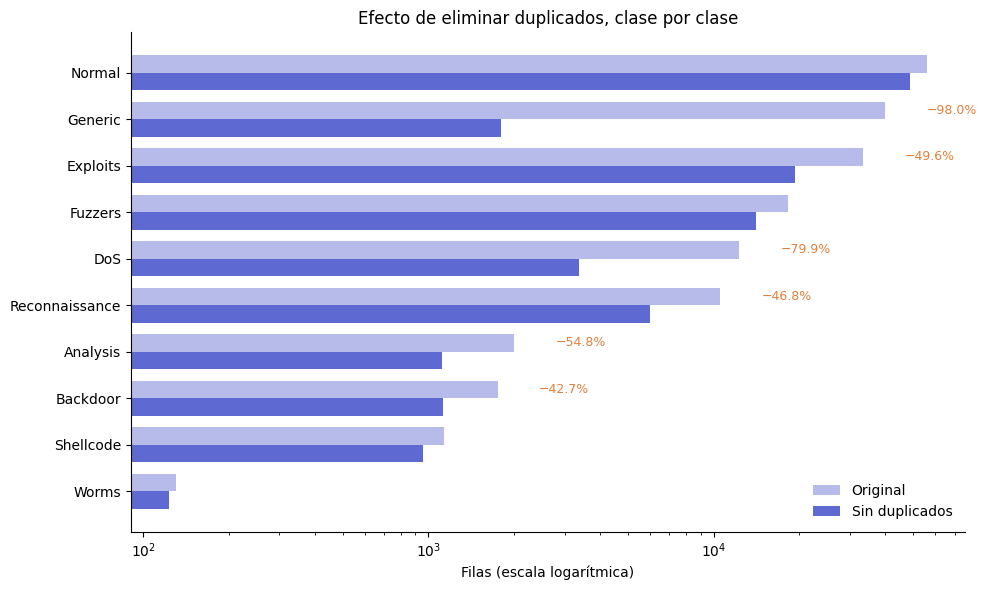

In [10]:
# Comparación visual entre lo que hay y lo que quedaría al quitar duplicados.
datos = dup_por_clase.sort_values("filas")
posicion = np.arange(len(datos))
alto = 0.38

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(posicion + alto / 2, datos["filas"], alto, label="Original", color=ACENTO, alpha=0.45)
ax.barh(posicion - alto / 2, datos["quedarian"], alto, label="Sin duplicados", color=ACENTO)

ax.set_yticks(posicion, datos.index)
ax.set_xscale("log")
ax.set_xlabel("Filas (escala logarítmica)")
ax.set_title("Efecto de eliminar duplicados, clase por clase")
ax.legend(frameon=False, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)

# Se anota la caída porcentual de las clases más afectadas.
for i, (nombre, fila) in enumerate(datos.iterrows()):
    if fila["pct_dup"] > 40:
        ax.text(fila["filas"] * 1.4, i + alto / 2, f"−{fila['pct_dup']}%",
                va="center", fontsize=9, color=AVISO)

plt.tight_layout()
RESULTADOS.mkdir(exist_ok=True)
fig.savefig(RESULTADOS / "duplicados-por-clase.png", dpi=140)
plt.show()

## 6. Fuga entre entrenamiento y prueba

Aquí aparece el problema serio.

Si una fila idéntica está a la vez en entrenamiento y en prueba, el modelo
aprobará el examen porque ya vio las respuestas. Se llama **fuga de datos** y
convierte cualquier métrica en papel mojado.

Como el dataset viene ya dividido desde Kaggle, conviene comprobar si esa
división está limpia. La comparación se hace **solo sobre las características**,
ignorando las etiquetas.

In [11]:
def firmas(df):
    """Convierte cada fila en una tupla para poder compararla entre conjuntos."""
    return list(map(tuple, df[caracteristicas].itertuples(index=False, name=None)))


vistas_en_train = set(firmas(train))
fugadas = np.array([f in vistas_en_train for f in firmas(test)])

print(f"Filas de prueba que aparecen idénticas en entrenamiento: "
      f"{fugadas.sum():,} de {len(test):,} ({fugadas.mean() * 100:.1f}%)")

Filas de prueba que aparecen idénticas en entrenamiento: 20,851 de 82,332 (25.3%)


In [12]:
fuga_por_clase = pd.DataFrame({
    "en_prueba": test[COLUMNA_CLASE].value_counts(),
    "fugadas": test.loc[fugadas, COLUMNA_CLASE].value_counts(),
}).fillna(0).astype(int)
fuga_por_clase["pct"] = (
    fuga_por_clase["fugadas"] / fuga_por_clase["en_prueba"] * 100
).round(1)

fuga_por_clase.sort_values("pct", ascending=False)

,en_prueba,fugadas,pct
attack_cat,,,
DoS,4089,2198,53.8
Generic,18871,9183,48.7
Reconnaissance,3496,1539,44.0
Analysis,677,248,36.6
Shellcode,378,84,22.2
Backdoor,583,127,21.8
Exploits,11132,2114,19.0
Fuzzers,6062,956,15.8
Normal,37000,4399,11.9


**La división oficial del dataset ya está contaminada.** Una cuarta parte del
conjunto de prueba estaba en el de entrenamiento, y en `DoS` la contaminación
supera la mitad.

Esto importa más allá de este proyecto: hay muchos cuadernos publicados que
presumen de accuracy sobre exactamente este conjunto de prueba.

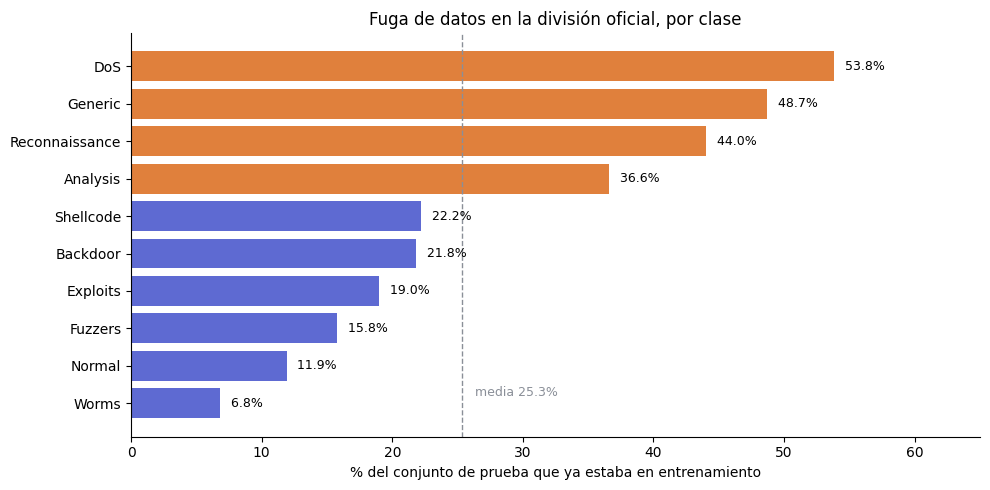

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
datos = fuga_por_clase.sort_values("pct")
colores = [AVISO if p > 25 else ACENTO for p in datos["pct"]]

barras = ax.barh(datos.index, datos["pct"], color=colores)
ax.bar_label(barras, labels=[f"  {p}%" for p in datos["pct"]], padding=2, fontsize=9)
ax.axvline(fugadas.mean() * 100, color="#8A8F98", linestyle="--", linewidth=1)
ax.text(fugadas.mean() * 100 + 1, 0.2, f"media {fugadas.mean() * 100:.1f}%",
        fontsize=9, color="#8A8F98")

ax.set_xlabel("% del conjunto de prueba que ya estaba en entrenamiento")
ax.set_title("Fuga de datos en la división oficial, por clase")
ax.set_xlim(0, 65)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
fig.savefig(RESULTADOS / "fuga-por-clase.png", dpi=140)
plt.show()

## 7. Preparación y guardado

La decisión tomada, y el porqué de cada parte:

- **Entrenamiento sin duplicados.** Filas idénticas no aportan información nueva,
  pero sí inflan el peso de una clase de forma artificial.

- **Dos conjuntos de prueba**, no uno:
  - `test_oficial` se deja tal cual. Sirve para comparar con lo que publica todo
    el mundo.
  - `test_limpio` quita las filas que ya estaban en entrenamiento. **Es el número
    honesto.**

**La diferencia entre ambos resultados es uno de los hallazgos del proyecto**, no
un detalle técnico que se pueda esconder.

In [14]:
train_limpio = train.drop_duplicates().reset_index(drop=True)
test_limpio = test.loc[~fugadas].drop_duplicates().reset_index(drop=True)

print(f"Entrenamiento: {len(train):,} -> {len(train_limpio):,} filas")
print(f"Prueba limpia: {len(test):,} -> {len(test_limpio):,} filas")

Entrenamiento: 175,341 -> 96,822 filas
Prueba limpia: 82,332 -> 47,716 filas


In [15]:
# Los tres repartos, uno al lado del otro, para ver cómo cambia el problema.
comparativa = pd.DataFrame({
    "train_limpio": train_limpio[COLUMNA_CLASE].value_counts(),
    "test_oficial": test[COLUMNA_CLASE].value_counts(),
    "test_limpio": test_limpio[COLUMNA_CLASE].value_counts(),
}).fillna(0).astype(int)

comparativa

,train_limpio,test_oficial,test_limpio
attack_cat,,,
Analysis,1119,677,250
Backdoor,1121,583,267
DoS,3369,4089,1378
Exploits,19360,11132,7280
Fuzzers,14082,6062,4139
Generic,1800,18871,1234
Normal,48894,37000,30924
Reconnaissance,6000,3496,1912
Shellcode,954,378,291


In [16]:
# Las clases con muy pocos ejemplos en prueba dan métricas inestables.
escasas = comparativa["test_limpio"][comparativa["test_limpio"] < 100]
if len(escasas):
    print("Clases con menos de 100 ejemplos en la prueba limpia:")
    for nombre, n in escasas.items():
        print(f"  {nombre}: {n} ejemplos -> cada acierto o fallo mueve el recall "
              f"{100 / n:.1f} puntos")
    print("\nEsto hay que decirlo al reportar los resultados.")

Clases con menos de 100 ejemplos en la prueba limpia:
  Worms: 41 ejemplos -> cada acierto o fallo mueve el recall 2.4 puntos

Esto hay que decirlo al reportar los resultados.


In [17]:
SALIDA.mkdir(exist_ok=True)
train_limpio.to_parquet(SALIDA / "train.parquet", index=False)
test.to_parquet(SALIDA / "test_oficial.parquet", index=False)
test_limpio.to_parquet(SALIDA / "test_limpio.parquet", index=False)

for archivo in sorted(SALIDA.glob("*.parquet")):
    print(f"{archivo.name:24} {archivo.stat().st_size / 1024**2:5.1f} MB")

test_limpio.parquet        3.7 MB
test_oficial.parquet       4.3 MB
train.parquet              7.4 MB


## Resumen

| Hallazgo | Dato |
|---|---|
| Clases | 10 |
| Proporción entre la mayor y la menor | 431 a 1 |
| Duplicados en entrenamiento | 44,8 % |
| Duplicados en la clase `Generic` | 98,0 % |
| Fuga en la división oficial | 25,3 % |
| Fuga en la clase `DoS` | 53,8 % |
| Baseline ingenuo | 31,94 % |

## Siguiente paso

Codificar las columnas de texto (`proto`, `service` y `state`) y entrenar el
primer modelo.

**Cuidado con otra fuga distinta:** el codificador debe ajustarse *solo* con el
conjunto de entrenamiento. Si se ajusta con los datos completos, la información
del conjunto de prueba se cuela por la puerta de atrás.
